In [2]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from sklearn.metrics import r2_score
import seaborn as sns
from datetime import datetime
from tabulate import tabulate
import pandas as pd

sns.set_theme(style='ticks', context='paper')

In [3]:
# Constants
ENERGY_CONSUMPTION = "Energy Consumption (exc. PUE)"
ENERGY_CONSUMPTION_PUE = "Energy Consumption (inc. PUE)"
MEMORY_CONSUMPTION = "Memory Energy Consumption (exc. PUE)"
MEMORY_CONSUMPTION_PUE = "Memory Energy Consumption (inc. PUE)"
CARBON_EMISSIONS = "Carbon Emissions"

In [4]:
# Trace File Paths List
workflows = ['chipseq', 'mag', 'montage', 'nanoseq', 'rangeland', 'rnaseq', 'sarek']
regions = ['Great Britain']#, 'Germany', 'California', 'Texas', 'South Africa', 'Tokyo', 'New South Wales']
short_regions = ['gb']#, 'de', 'ca', 'tx', 'zaf', 'tyo', 'nsw']
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
short_months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'] 
month_dates = ['08012024-13012024', '12022024-17022024', '11032024-16032024',  
    '08042024-13042024', '13052024-18052024', '10062024-15062024',  
    '08072024-13072024', '12082024-17082024', '09092024-14092024',  
    '14102024-19102024', '11112024-16112024', '09122024-14122024']
region_folders = [f'../data/results/interrupt-wf-shifting/out/{region}/' for region in short_regions]
windows = [6, 12, 24, 48, 96]

In [5]:
def get_max_overhead(overheads):
    oh_1, _ = overheads[0].split('|')
    oh_2, _ = overheads[1].split('|')
    oh_3, _ = overheads[2].split('|')

    return max([float(oh_1), float(oh_2), float(oh_3)])
    

def parse_ts_summary_file(file):
    with open(file, 'r') as f:
        lines = f.readlines()[1:]

    props = {}

    for line in lines:
        parts = line.split(',')
        workflow = parts[0].split('-')[0]
        footprint = float(parts[1])
        makespan = float(parts[2])
        entry_6h = parts[3].split(':')
        entry_12h = parts[4].split(':')
        entry_24h = parts[5].split(':')
        entry_48h = parts[6].split(':')
        entry_96h = parts[7].split(':')

        if len(props) == 0:
            props = {
                "FOOTPRINT": [footprint],
                "MAKESPAN": [makespan],
                "6H_FOOTPRINT": [float(entry_6h[1])],
                "6H_REDUCTION": [float(entry_6h[0][:-1])],
                "6H_OVERHEAD": [entry_6h[2]],
                "12H_FOOTPRINT": [float(entry_12h[1])],
                "12H_REDUCTION": [float(entry_12h[0][:-1])],
                "12H_OVERHEAD": [entry_12h[2]],
                "24H_FOOTPRINT": [float(entry_24h[1])],
                "24H_REDUCTION": [float(entry_24h[0][:-1])],
                "24H_OVERHEAD": [entry_24h[2]],
                "48H_FOOTPRINT": [float(entry_48h[1])],
                "48H_REDUCTION": [float(entry_48h[0][:-1])],
                "48H_OVERHEAD": [entry_48h[2]],
                "96H_FOOTPRINT": [float(entry_96h[1])],
                "96H_REDUCTION": [float(entry_96h[0][:-1])],
                "96H_OVERHEAD": [entry_96h[2]]
            }
        else: 
            props["FOOTPRINT"].append(footprint)
            props["MAKESPAN"].append(makespan)
            props["6H_FOOTPRINT"].append(float(entry_6h[1]))
            props["6H_REDUCTION"].append(float(entry_6h[0][:-1]))
            props["6H_OVERHEAD"].append(entry_6h[2])
            props["12H_FOOTPRINT"].append(float(entry_12h[1]))
            props["12H_REDUCTION"].append(float(entry_12h[0][:-1]))
            props["12H_OVERHEAD"].append(entry_12h[2])
            props["24H_FOOTPRINT"].append(float(entry_24h[1]))
            props["24H_REDUCTION"].append(float(entry_24h[0][:-1]))
            props["24H_OVERHEAD"].append(entry_24h[2])
            props["48H_FOOTPRINT"].append(float(entry_48h[1]))
            props["48H_REDUCTION"].append(float(entry_48h[0][:-1]))
            props["48H_OVERHEAD"].append(entry_48h[2])
            props["96H_FOOTPRINT"].append(float(entry_96h[1]))
            props["96H_REDUCTION"].append(float(entry_96h[0][:-1]))
            props["96H_OVERHEAD"].append(entry_96h[2])

    data = {}
    wf_makespan = sum(props["MAKESPAN"]) / 3
    footprint_6h = sum(props["6H_FOOTPRINT"]) / 3
    reduction_6h = sum(props["6H_REDUCTION"]) / 3
    max_overhead_6h = get_max_overhead(props["6H_OVERHEAD"])
    footprint_12h = sum(props["12H_FOOTPRINT"]) / 3
    reduction_12h = sum(props["12H_REDUCTION"]) / 3

    if reduction_12h < reduction_6h:
        reduction_12h = reduction_6h

    max_overhead_12h = get_max_overhead(props["12H_OVERHEAD"])
    footprint_24h = sum(props["24H_FOOTPRINT"]) / 3
    reduction_24h = sum(props["24H_REDUCTION"]) / 3

    if reduction_24h < reduction_12h:
        reduction_24h = reduction_12h

    max_overhead_24h = get_max_overhead(props["24H_OVERHEAD"])
    footprint_48h = sum(props["48H_FOOTPRINT"]) / 3
    reduction_48h = sum(props["48H_REDUCTION"]) / 3

    if reduction_48h < reduction_24h:
        reduction_48h = reduction_24h

    max_overhead_48h = get_max_overhead(props["48H_OVERHEAD"])
    footprint_96h = sum(props["96H_FOOTPRINT"]) / 3
    reduction_96h = sum(props["96H_REDUCTION"]) / 3

    if reduction_96h < reduction_48h:
        reduction_96h = reduction_48h

    max_overhead_96h = get_max_overhead(props["6H_OVERHEAD"])

    data = {
        "FOOTPRINT": sum(props["FOOTPRINT"]) / 3,
        "MAKESPAN": wf_makespan,
        "6H_REDUCTION": reduction_6h,
        "6H_OVERHEAD":  max_overhead_6h,
        "6H_FOOTPRINT": footprint_6h,
        "12H_REDUCTION":  reduction_12h,
        "12H_OVERHEAD":  max_overhead_12h,
        "12H_FOOTPRINT": footprint_12h,
        "24H_REDUCTION":  reduction_24h,
        "24H_OVERHEAD":  max_overhead_24h,
        "24H_FOOTPRINT": footprint_24h,
        "48H_REDUCTION":  reduction_48h,
        "48H_OVERHEAD":  max_overhead_48h,
        "48H_FOOTPRINT": footprint_48h,
        "96H_REDUCTION":  reduction_96h,
        "96H_OVERHEAD":  max_overhead_96h,
        "96H_FOOTPRINT": footprint_96h,
    }

    return data
        

In [6]:
def write_to_file(outfile, data, headers):
    with open(f'../data/results/interrupt-wf-shifting/out/{outfile}', 'w') as f:
        f.write(','.join(headers) + '\n')

        for row in data:
            f.write(','.join(row) + '\n')

# purpose illustrating impact of pausing on overall footprint
- here, we consider the overhead in seconds, and convert this to a time in h
- we use this time to then account for memory energy consumption, where this considers all of the memory in the nodes used
- e.g. 256GB on all 8 nodes, assuming that data is stored here for time spent waiting (the overhead)
- this used the constant 0.392W/GB [[WHAT ARE THE STORAGE COSTS? disks/ssds (lookup)]], and average CI data from 2023 UK -- 215gCO2e
  - disk embodied emissions (Youssef?)
  - stored energy costs (pick upper bound of intermediate storage? total bytes written/read?)
>> 2024 United States Data Center Energy Usage Report
    - https://escholarship.org/uc/item/32d6m0d1
    - has some broad figures e.g. 11W/6W/6.5W/disk (how big is the disk, how many disk, how does this occur over time?)
>> Energy-aware operation of HPC systems in Germany
    - https://www.frontiersin.org/journals/high-performance-computing/articles/10.3389/fhpcp.2025.1520207/full (to be read)
- here, we see that there is little change to the overall reduction in footprint, with minimal emissions added on

nanoseq server -- 512GB SSD
hu cluster -- 2 x 3.5 TB SSD (ask for more info?)
tu cluster -- 2 SATA III SSDs with 960GB

In [7]:
# Interrupting Footprints - Average CI
headers = ["Region", "Month", "Workflow", "Original Footprint (gCO2e)", "Makespan (s)", 
           "Reduction 6h (%)", "Overhead 6h", "FP 6h",
           "Reduction 12h (%)", "Overhead 12h", "FP 12h",
           "Reduction 24h (%)", "Overhead 24h", "FP 24h",
           "Reduction 48h (%)", "Overhead 48h", "FP 48h",
           "Reduction 96h (%)","Overhead 96h", "FP 96h"]
data_avg_tbl = []
data_avg_dct = {}

for region, region_base in zip(short_regions, region_folders):
    if region not in data_avg_dct:
        data_avg_dct[region] = {}
    for month in short_months:
        for workflow in workflows:
            if workflow not in data_avg_dct[region]:
                data_avg_dct[region][workflow] = {}
            if month not in data_avg_dct[region][workflow]:
                data_avg_dct[region][workflow][month] = {} 
            temp = parse_ts_summary_file(f'{region_base}{workflow}-{month}-avg-ts.csv')
            span = temp["MAKESPAN"]
            data_avg_tbl.append([region, month, workflow,f'{temp["FOOTPRINT"]:.2f}', f'{span:.0f}', 
                 f"{temp['6H_REDUCTION']:.2f}", f"{temp['6H_OVERHEAD']:.2f}", f"{temp['6H_FOOTPRINT']:.2f}",
                 f"{temp['12H_REDUCTION']:.2f}", f"{temp['12H_OVERHEAD']:.2f}", f"{temp['12H_FOOTPRINT']:.2f}",
                 f"{temp['24H_REDUCTION']:.2f}", f"{temp['24H_OVERHEAD']:.2f}", f"{temp['24H_FOOTPRINT']:.2f}",
                 f"{temp['48H_REDUCTION']:.2f}", f"{temp['48H_OVERHEAD']:.2f}", f"{temp['48H_FOOTPRINT']:.2f}",
                 f"{temp['96H_REDUCTION']:.2f}", f"{temp['96H_OVERHEAD']:.2f}", f"{temp['96H_FOOTPRINT']:.2f}"])

            data_avg_dct[region][workflow][month][6] = temp['6H_REDUCTION']
            data_avg_dct[region][workflow][month][12] = temp['12H_REDUCTION']
            data_avg_dct[region][workflow][month][24] = temp['24H_REDUCTION']
            data_avg_dct[region][workflow][month][48] = temp['48H_REDUCTION']
            data_avg_dct[region][workflow][month][96] = temp['96H_REDUCTION']


# Accounting Example (marginal doesn't make much sense -- this is for the discussion)
limited_df = pd.DataFrame.from_records(data_avg_tbl, columns=headers)
limited_df = limited_df.drop(columns=['Region', 'Month'])
limited_df['OrFP'] = limited_df['Original Footprint (gCO2e)'].astype(float)
limited_df['span_s'] = limited_df['Makespan (s)'].astype(float)
limited_df['red_6h_per'] = limited_df['Reduction 6h (%)'].astype(float)
limited_df['red_12h_per'] = limited_df['Reduction 12h (%)'].astype(float)
limited_df['red_24h_per'] = limited_df['Reduction 24h (%)'].astype(float)
limited_df['red_48h_per'] = limited_df['Reduction 48h (%)'].astype(float)
limited_df['red_96h_per'] = limited_df['Reduction 96h (%)'].astype(float)
limited_df['oh_6h_s'] = limited_df['Overhead 6h'].astype(float)
limited_df['oh_12h_s'] = limited_df['Overhead 12h'].astype(float)
limited_df['oh_24h_s'] = limited_df['Overhead 24h'].astype(float)
limited_df['oh_48h_s'] = limited_df['Overhead 48h'].astype(float)
limited_df['oh_96h_s'] = limited_df['Overhead 96h'].astype(float)
limited_df['fp_6h'] = limited_df['FP 6h'].astype(float)
limited_df['fp_12h'] = limited_df['FP 12h'].astype(float)
limited_df['fp_24h'] = limited_df['FP 24h'].astype(float)
limited_df['fp_48h'] = limited_df['FP 48h'].astype(float)
limited_df['fp_96h'] = limited_df['FP 96h'].astype(float)
avg = limited_df.groupby(['Workflow']).mean(numeric_only=True).reset_index()

for workflow, node_mem, nodes in zip(workflows, [128, 256, 128, 32, 256, 128, 128], [8, 8, 8, 1, 8, 8, 8]):
    row = avg[avg['Workflow'] == workflow].iloc[0].to_dict()
    # mem_oh_24h_energy = node_mem * nodes * 0.392 * (row['oh_24h_s'] / 3600) * 0.001  # convert from W to kW
    # mem_oh_24h_ems = mem_oh_24h_energy * 215
    # tot_24h_ems = mem_oh_24h_ems + row['fp_24h']
    # mem_oh_96h_energy = node_mem * nodes * 0.392 * (row['oh_96h_s'] / 3600) * 0.001  # convert from W to kW
    # mem_oh_96h_ems = mem_oh_96h_energy * 215
    # tot_96h_ems = mem_oh_96h_ems + row['fp_96h']

    print(f'{workflow} Original Footprint [{row['OrFP']:.2f}gCO2e] Makespan [{row['span_s'] / 3600:.2f}h] Overhead 24h [{row['oh_24h_s'] / 3600:.2f}h] Overhead 96h [{row['oh_96h_s'] / 3600:.2f}h]')
    # print(f'24H Overhead {mem_oh_24h_ems:.2f}gCO2e Total {tot_24h_ems:.2f}gCO2e Reduction {(row['OrFP'] - tot_24h_ems) /  row['OrFP'] * 100:.2f}% prev. {row['red_24h_per']:.2f}%')
    # print(f'96h Overhead {mem_oh_96h_ems:.2f}gCO2e Total {tot_96h_ems:.2f}gCO2e Reduction {(row['OrFP'] - tot_96h_ems) / row['OrFP'] * 100:.2f}% prev. {row['red_96h_per']:.2f}%')
    # re ichnos, National Grid Average CI in 2023 is 215gCO2e (rough estimation)


chipseq Original Footprint [933.42gCO2e] Makespan [3.70h] Overhead 24h [0.05h] Overhead 96h [0.03h]
mag Original Footprint [2787.17gCO2e] Makespan [12.63h] Overhead 24h [0.77h] Overhead 96h [0.73h]
montage Original Footprint [53.11gCO2e] Makespan [0.53h] Overhead 24h [0.00h] Overhead 96h [0.00h]
nanoseq Original Footprint [47.48gCO2e] Makespan [5.56h] Overhead 24h [0.11h] Overhead 96h [0.02h]
rangeland Original Footprint [1345.35gCO2e] Makespan [6.89h] Overhead 24h [0.05h] Overhead 96h [0.03h]
rnaseq Original Footprint [671.18gCO2e] Makespan [3.06h] Overhead 24h [0.13h] Overhead 96h [0.13h]
sarek Original Footprint [1203.44gCO2e] Makespan [5.07h] Overhead 24h [0.33h] Overhead 96h [0.06h]


In [8]:
# Constants
regions = ['Great Britain', 'Germany', 'California', 'Texas', 'South Africa', 'Tokyo', 'New South Wales']
short_regions = ['gb', 'de', 'ca', 'tx', 'zaf', 'tyo', 'nsw']
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
short_months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'] 
month_dates = ['08012024-13012024', '12022024-17022024', '11032024-16032024',  
    '08042024-13042024', '13052024-18052024', '10062024-15062024',  
    '08072024-13072024', '12082024-17082024', '09092024-14092024',  
    '14102024-19102024', '11112024-16112024', '09122024-14122024']
region_folders = [f'../data/results/entire-wf-shifting/out-err/{region}/' for region in short_regions]
workflows=['chipseq', 'mag', 'montage', 'nanoseq', 'rangeland', 'rnaseq', 'sarek']

In [9]:
# Parse Explorer Summary (NEW)
def parse_explorer_summary(explorer_data):
    with open(explorer_data, 'r') as f:
        data = [line.strip().split(',') for line in f.readlines()]

    for row in data:
        if '~' in row[0]:
            shift_ms = row[0].split('~')[1][:-4]
            days = int(shift_ms.split('-')[0])
            hours = int(shift_ms.split('-')[1])
            shift_h = (days * 24) + hours
            row[0] = shift_h
        else:
            row[0] = 0

    data_d = {}

    for row in data:
        data_d[row[0]] = {'emissions': row[1]}

    return data_d


def get_minimum(data):
    minimum = float(data[0]['emissions'])
    shift = 0

    for key, entry in data.items():
        if float(entry['emissions']) < minimum:
            minimum = float(entry['emissions'])
            shift = key

    return (shift, minimum)


def get_reduction(original, new):
    orig = float(original)
    neww = float(new)
    return ((orig - neww) / abs(orig)) * 100


def overview(trace, print=False):
    data = parse_explorer_summary(trace)
    (min_shift, min_emissions) = get_minimum(data)

    if print:
        print(f"Original [0] CCF {data[0]['emissions']} gCO2e")  # original
        print(f"Minimum [{min_shift}] CCF {min_emissions} gCO2e")  # minimum
        print(f"Reduction {get_reduction(data[0]['emissions'], min_emissions):.2f}%")

    return (data, min_shift, min_emissions)


def average(one, two, three):
    return (float(one) + float(two) + float(three)) / 3

In [10]:
# Parse Readings for all readings, through the year
def parse_readings(window, marg='', err='', region='gb', folder=f'../data/results/entire-wf-shifting/out-err/{region}/'):
    if err == '':
        reduction_by_workflow = {}

        for i in range(0, 12):
            for workflow in workflows:
                path_one = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-1-{region}-{month_dates[i]}{err}{marg}~footprint.csv'
                path_two = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-2-{region}-{month_dates[i]}{err}{marg}~footprint.csv'
                path_three = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-3-{region}-{month_dates[i]}{err}{marg}~footprint.csv'

                (data_1, _, min_emissions_1) = overview(path_one)
                (data_2, _, min_emissions_2) = overview(path_two)
                (data_3, _, min_emissions_3) = overview(path_three)
                avg_orig_ems = average(data_1[0]['emissions'], data_2[0]['emissions'], data_3[0]['emissions'])
                avg_min_ems = average(min_emissions_1, min_emissions_2, min_emissions_3)
                avg_reduction = get_reduction(avg_orig_ems, avg_min_ems)

                if workflow in reduction_by_workflow:
                    reduction_by_workflow[workflow].append(avg_reduction)
                else:
                    reduction_by_workflow[workflow] = [avg_reduction]

        return reduction_by_workflow

    data = {}

    for rep in range(1, 6):
        reduction_by_workflow = {}

        for i in range(0, 12):
            for workflow in workflows:
                path_one = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-1-{region}-{month_dates[i]}{err}-{rep}{marg}~footprint.csv'
                path_two = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-2-{region}-{month_dates[i]}{err}-{rep}{marg}~footprint.csv'
                path_three = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-3-{region}-{month_dates[i]}{err}-{rep}{marg}~footprint.csv'

                (data_1, _, min_emissions_1) = overview(path_one)
                (data_2, _, min_emissions_2) = overview(path_two)
                (data_3, _, min_emissions_3) = overview(path_three)
                avg_orig_ems = average(data_1[0]['emissions'], data_2[0]['emissions'], data_3[0]['emissions'])
                avg_min_ems = average(min_emissions_1, min_emissions_2, min_emissions_3)
                avg_reduction = get_reduction(avg_orig_ems, avg_min_ems)

                if workflow in reduction_by_workflow:
                    reduction_by_workflow[workflow].append(avg_reduction)
                else:
                    reduction_by_workflow[workflow] = [avg_reduction]
    
        data[rep] = reduction_by_workflow

    return data

## Sensitivity Analysis
- CI forecasting -- error of 5% and then 10%
- using our entire workflow shifting experiment (original times, times with 5% noise, times with 10% noise)
  - takes a long time to generate all files, so in progress
- r2 score when using 5% for the 24h experiment has an r2 score of around 0.815 (interpret?)
  - visual comparison of reduction values looks similar, +- a few % on the reduction for each one
- think it's a logical assumption to be like, yes the method is dependent on the quality of the forecast
  - only real signal we have to go off
  - as they become more accurate, so do the potential reductions

In [38]:
## Sensitivity Analysis - CI Experiments [24: 5, 10, 15 ~~ 96: 5, 10, 15]
region = 'gb'

# Average CI (24h)
read_24h = parse_readings(window=24)
curr = []
for workflow in workflows:
    curr.append(read_24h[workflow])
reads_24h_original = np.array(curr)

# Error 5% (24h)
reads_24h_err5 = parse_readings(window=24, err='-err5')
all_reads_24h_err5 = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_24h_err5[iter][workflow])
    all_reads_24h_err5.append(np.array(curr))
reads_24h_err5_mean = np.mean(all_reads_24h_err5, axis=0)

# Error 10% (24h)
reads_24h_err10 = parse_readings(window=24, err='-err10')
all_reads_24h_err10 = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_24h_err10[iter][workflow])
    all_reads_24h_err10.append(np.array(curr))
reads_24h_err10_mean = np.mean(all_reads_24h_err10, axis=0)

# Error 15% (24h)
reads_24h_err15 = parse_readings(window=24, err='-err15')
all_reads_24h_err15 = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_24h_err15[iter][workflow])
    all_reads_24h_err15.append(np.array(curr))
reads_24h_err15_mean = np.mean(all_reads_24h_err15, axis=0)

# Average CI (96h)
read_96h = parse_readings(window=96)
curr = []
for workflow in workflows:
    curr.append(read_96h[workflow])
reads_96h_original = np.array(curr)

# Error 5% (24h)
reads_96h_err5 = parse_readings(window=96, err='-err5')
all_reads_96h_err5 = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_96h_err5[iter][workflow])
    all_reads_96h_err5.append(np.array(curr))
reads_96h_err5_mean = np.mean(all_reads_96h_err5, axis=0)

# Error 10% (96h)
reads_96h_err10 = parse_readings(window=96, err='-err10')
all_reads_96h_err10 = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_96h_err10[iter][workflow])
    all_reads_96h_err10.append(np.array(curr))
reads_96h_err10_mean = np.mean(all_reads_96h_err10, axis=0)

# Error 15% (96h)
reads_96h_err15 = parse_readings(window=96, err='-err15')
all_reads_96h_err15 = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_96h_err15[iter][workflow])
    all_reads_96h_err15.append(np.array(curr))
reads_96h_err15_mean = np.mean(all_reads_96h_err15, axis=0)

def summarise(orig, err, err_v):
    print(f'Comparison using {err_v}% with CI Forecast')

    orig_total = 0
    for workflow, i in zip(workflows, range(0, 7)):
        orig_total += np.average(orig[i])

    total = 0
    for workflow, i in zip(workflows, range(0, 7)):
        # print(f'[{workflow}] mean reduction: {np.average(orig[i]):.2f}% 5err: {np.average(err[i]):.2f}%')
        total += np.average(np.average(err[i]))

    print(f'Mean Reduction (orig): {orig_total / 7:.2f}%')
    print(f'Mean Reduction ({err_v}%): {total / 7:.2f}%')

    return (orig_total / 7, total / 7)

In [12]:
# average case -- down/up?
# e.g. on average we had a 50% saving, and on average it's a -5% impact (w/ noise e.g.)
# 15% noise would be better 
# workflow level? for entire workflow shifting -? e.g. workflow 6h, predicted 6.5h, what time vs. actual 6h (picking the best window)

In [39]:
res_24_5 = summarise(reads_24h_original, reads_24h_err5_mean, '(24h) 5')
print('---')
res_96_5 = summarise(reads_96h_original, reads_96h_err5_mean, '(96h) 5')

Comparison using (24h) 5% with CI Forecast
Mean Reduction (orig): 33.95%
Mean Reduction ((24h) 5%): 34.24%
---
Comparison using (96h) 5% with CI Forecast
Mean Reduction (orig): 43.49%
Mean Reduction ((96h) 5%): 44.00%


In [40]:
res_24_10 = summarise(reads_24h_original, reads_24h_err10_mean, '(24h) 10')
print('---')
res_96_10 = summarise(reads_96h_original, reads_96h_err10_mean, '(96h) 10')

Comparison using (24h) 10% with CI Forecast
Mean Reduction (orig): 33.95%
Mean Reduction ((24h) 10%): 34.88%
---
Comparison using (96h) 10% with CI Forecast
Mean Reduction (orig): 43.49%
Mean Reduction ((96h) 10%): 45.38%


In [41]:
res_24_15 = summarise(reads_24h_original, reads_24h_err15_mean, '(24h) 15')
print('---')
res_96_15 = summarise(reads_96h_original, reads_96h_err15_mean, '(96h) 15')

Comparison using (24h) 15% with CI Forecast
Mean Reduction (orig): 33.95%
Mean Reduction ((24h) 15%): 35.97%
---
Comparison using (96h) 15% with CI Forecast
Mean Reduction (orig): 43.49%
Mean Reduction ((96h) 15%): 47.75%


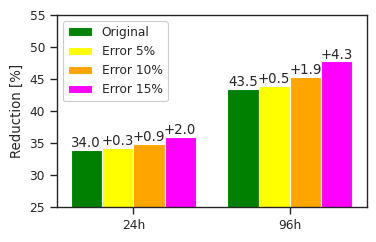

In [103]:
fig, ax = plt.subplots(figsize=(4,2.5))

# orig 24
width = 0.05
padding = 0.03
x = 2
y = 2.25

# 24h
orig_24 = ax.bar(x - width * 1.5, res_24_5[0], width, label='Original', color='green')
bar_24_5 = ax.bar(x - width * 0.5, res_24_5[1], width, label='Error 5%', color='yellow')
bar_24_10 = ax.bar(x + width * 0.5, res_24_10[1], width, label='Error 10%', color='orange')
bar_24_15 = ax.bar(x + width * 1.5, res_24_15[1], width, label='Error 15%', color='magenta')

ax.bar_label(orig_24, labels=[f'{round(res_24_5[0], 1)}'])
ax.bar_label(bar_24_5, labels=[f'+{round(res_24_5[1] - res_24_5[0], 1)}'])
ax.bar_label(bar_24_10, labels=[f'+{round(res_24_10[1] - res_24_5[0], 1)}'])
ax.bar_label(bar_24_15, labels=[f'+{round(res_24_15[1] - res_24_5[0], 1)}'])

# 96h
orig_96 = ax.bar(y - width * 1.5, res_96_5[0], width, label='Original', color='green')
bar_96_5 = ax.bar(y - width * 0.5, res_96_5[1], width, label='Error 5%', color='yellow')
bar_96_10 = ax.bar(y + width * 0.5, res_96_10[1], width, label='Error 10%', color='orange')
bar_96_15 = ax.bar(y + width * 1.5, res_96_15[1], width, label='Error 15%', color='magenta')

ax.bar_label(orig_96, labels=[f'{round(res_96_5[0], 1)}'])
ax.bar_label(bar_96_5, labels=[f'+{round(res_96_5[1] - res_96_5[0], 1)}'])
ax.bar_label(bar_96_10, labels=[f'+{round(res_96_10[1] - res_96_5[0], 1)}'])
ax.bar_label(bar_96_15, labels=[f'+{round(res_96_15[1] - res_96_5[0], 1)}'])

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left', ncols=1, framealpha=1)

xticks = [x, y]
xlabels = ['24h', '96h']
ax.set_xticks(xticks, xlabels)
ax.set_ylabel('Reduction [%]')
ax.set_ylim(25,55)

plt.savefig(f'../image/ci-sensitivity-analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# not 100% sure if it makes sense to blindly adjust timestamps of a workflow to make tasks have 'inaccurate predictions'ArithmeticError
# thinking about having some illustrative examples, if we imagine that we have a prediction error of X
# workflow could take Y longer, which leads to footprint increase by Z
# any method is reliant on having reliable predictions of runtime 

# will try adding noise but i dont know if it makes sense at all

In [17]:
# Workflow read and write bytes
def get_read_write_workflow(workflow, iteration):
    with open(f'../data/traces/workflows/{workflow}/{workflow}-{iteration}.csv', 'r') as file:
        lines = file.readlines()[1:]

    read = 0
    write = 0

    for line in lines:
        parts = line.split(',')
        try:
            read += float(parts[32].strip())
            write ++ float(parts[33].strip())
        except ValueError:
            read += 0
            write += 0

    read /= 1073741824  # convert B to GB
    write /= 1073741824  # convert B to GB

    return (read, write)

def read_file_get_day(file, day):
    with open(f'../data/intensity/out/gb-{file}.csv', 'r') as file:
        raw = file.readlines()[1:]

    map = {}
    for line in raw:
        parts = line.split(',')
        if parts[0] == day:
            map[int(parts[1].split(':')[0])] = float(parts[2])
    
    return map

def min_consecutive_window(data, n):
    min_sum = float("inf")
    min_start = None

    for start in range(0, len(data) - n + 1):
        window_sum = sum(data[i] for i in range(start, start + n))

        if window_sum < min_sum:
            min_sum = window_sum
            min_start = start

    return {
        "start": min_start,
        "end": min_start + n - 1,
        "sum": min_sum,
        "values": {i: data[i] for i in range(min_start, min_start + n)}
    }

def weighted_sum(values, start_index, end_index, arr):
    return sum(
        arr[i] * values[start_index + i]
        for i in range(end_index - start_index)
    )

In [28]:
for workflow in workflows:
    r, w = get_read_write_workflow(workflow, 1)
    print(workflow, r, 'GB', w, 'GB')


chipseq 226.45562362670898 GB 0.0 GB
mag 36.01768493652344 GB 0.0 GB
montage 0.000301361083984375 GB 0.0 GB
nanoseq 69.85449981689453 GB 0.0 GB
rangeland 8.319229125976562 GB 0.0 GB
rnaseq 700.4939384460449 GB 0.0 GB
sarek 685.7082366943359 GB 0.0 GB


In [19]:
day = read_file_get_day('08042024-13042024', '2024-04-11')
best_5 = min_consecutive_window(day, 5)
best_6 = min_consecutive_window(day, 6)
workflow_even = [1, 1, 1, 1, 1]
print('original fp', weighted_sum(day, 1, 5, workflow_even))

print('predicted 5h (actual)')
print(best_5['start'], '-', best_5['end'])
print('even', weighted_sum(day, best_5['start'], best_5['start'] + 4, workflow_even))

print('predicted 6h')
print(best_6['start'], '-', best_6['end'])
print('even', weighted_sum(day, best_6['start'], best_6['start'] + 4, workflow_even))



original fp 186.29
predicted 5h (actual)
10 - 14
even 166.08
predicted 6h
9 - 14
even 181.06


In [20]:
# Add Runtime Noise to a Workflow? 
def add_noise_for_workflow(workflow_file_in, workflow_file_out, noise):
    df = pd.read_csv(f'{workflow_file_in}.csv')

    for rep in range(1, 6):
        rng = np.random.default_rng(rep)
        df['complete'] = df['complete'] + rng.normal(0, noise * df['complete'].mean() / 10000000, size=len(df['complete'])) 
        # important to consider error but ensure meaningful, e.g. change of minutes instead of hours
        df.to_csv(f'{workflow_file_out}-{rep}.csv', sep=',', index=False, encoding='utf-8')


In [21]:
for workflow in workflows:
    wf_in = f'../data/traces/workflows/{workflow}/{workflow}-1'
    wf_out = f'../data/traces/workflows/noisy/{workflow}'
    add_noise_for_workflow(wf_in, wf_out, 0.15)

In [22]:
# Compare noisy runtime workflows with original executions (average of both)
REGION='gb'
FOLDER=f'../data/results/entire-wf-shifting/out-runtime/{REGION}/' 

reads_24h_orig = parse_readings(window=24, err='', region=REGION, folder='../data/results/entire-wf-shifting/out/gb/')
curr = []
for workflow in workflows:
    curr.append(read_24h[workflow])
reads_24h_orig = np.array(curr)

reads_15err = parse_readings(window=24, err='-15err', region=REGION, folder=FOLDER)
all_reads_15err = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_15err[iter][workflow])
    all_reads_15err.append(np.array(curr))
reads_15err_mean = np.mean(all_reads_15err, axis=0)


# make new based on run-entire-wf-shifting-with-err in entire-wf-shifting 


FileNotFoundError: [Errno 2] No such file or directory: '../data/results/entire-wf-shifting/out-runtime/gb/explorer-24h-chipseq-jan-1-gb-08012024-13012024-15err-1~footprint.csv'